#### Imports and config

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text

#### MySQL connection

In [3]:
# ── Connect to MySQL ──────────────────────────────────────────
DB_USER     = "root"
DB_PASSWORD = "root123"
DB_HOST     = "localhost"
DB_PORT     = 3306
DB_NAME     = "fintech_risk"

engine = create_engine(
    f"mysql+mysqlconnector://{DB_USER}:{DB_PASSWORD}"
    f"@{DB_HOST}:{DB_PORT}/{DB_NAME}",
    pool_pre_ping=True
)

#### Load tables

In [4]:
# ── Load all three source tables ──────────────────────────────
loans        = pd.read_sql("SELECT * FROM loans",        engine, parse_dates=["disbursal_date"])
repayments   = pd.read_sql("SELECT * FROM repayments",   engine, parse_dates=["due_date","paid_date"])
transactions = pd.read_sql("SELECT * FROM transactions", engine, parse_dates=["txn_date"])

#### Identify DPD30 events
    A DPD30 "event" is the FIRST time a loan crosses DPD30 — not every subsequent row where it remains DPD30+. 
    We want the moment of onset, since that's what we're trying to predict, not the ongoing state.

In [5]:
rep = repayments.merge(
    loans[["loan_id", "customer_id", "disbursal_date"]],
    on="loan_id", how="left"
)

In [6]:
# MOB for sequencing (same logic as the SQL views)
rep["mob"] = (
    (rep["due_date"].dt.year  - rep["disbursal_date"].dt.year) * 12 +
    (rep["due_date"].dt.month - rep["disbursal_date"].dt.month)
)
rep = rep.sort_values(["loan_id", "mob"])

# Flag DPD30+ rows
rep["is_dpd30"] = rep["dpd"] >= 30

In [8]:
# Step 1: First DPD30 occurrence per loan — this is the event we care about
dpd30_events = (
    rep[rep["is_dpd30"]]
    .groupby("loan_id")
    .first()
    .reset_index()[["loan_id", "customer_id", "due_date"]]
    .rename(columns={"due_date": "event_date"})
)

print(f"Total DPD30 events identified: {len(dpd30_events):,}")
print(dpd30_events.head())

Total DPD30 events identified: 33,183
      loan_id  customer_id event_date
0  LN00000001  CUST0013536 2024-08-26
1  LN00000002  CUST0028028 2025-11-05
2  LN00000003  CUST0019977 2026-07-15
3  LN00000004  CUST0017979 2026-12-30
4  LN00000006  CUST0016347 2024-02-03


In [9]:
# Step 2: broad merge (vectorized — fast)
merged=transactions.merge(dpd30_events,on="customer_id",how="inner")

In [11]:
window_mask = (
    (merged["txn_date"] >= merged["event_date"] - pd.Timedelta(days=30)) &
    (merged["txn_date"] <  merged["event_date"])
)

In [12]:
# Step 3: date-mask filter to two windows
pre_default_txns = merged[window_mask].copy()

In [13]:
print(f"Transactions in pre-default windows: {len(pre_default_txns):,}")
print(f"Unique DPD30 events with at least 1 txn in window: "
      f"{pre_default_txns['loan_id'].nunique():,}")

Transactions in pre-default windows: 9,131
Unique DPD30 events with at least 1 txn in window: 7,721


#### Build a baseline window for comparison
    For each customer, take a "normal" window — 30 days, but from 90-120 days BEFORE the event, well outside the pre-default stress zone. 
    This becomes our control: same customer, different time period.

In [15]:
baseline_mask = (
    (merged["txn_date"] >= merged["event_date"] - pd.Timedelta(days=120)) &
    (merged["txn_date"] <  merged["event_date"] - pd.Timedelta(days=90))
)

baseline_txns = merged[baseline_mask].copy()

print(f"Transactions in baseline windows: {len(baseline_txns):,}")

Transactions in baseline windows: 9,131


#### Signal 1 — Decline rate spike

In [16]:
window_decline = pre_default_txns.groupby("loan_id")["is_declined"].mean().rename("window_decline")

In [17]:
base_decline = baseline_txns.groupby("loan_id")["is_declined"].mean().rename("base_decline")

In [20]:
signal_1 = pd.concat([window_decline, base_decline], axis=1).fillna(0)
signal_1["decline_rate_change"] = signal_1["window_decline"] - signal_1["base_decline"]
signal_1["decline_spike_flag"] = (signal_1["window_decline"] >= signal_1["base_decline"] * 2).astype(int)

In [21]:
signal_1.head()

,window_decline,base_decline,decline_rate_change,decline_spike_flag
loan_id,,,,
LN00000003,0.0,0.0,0.0,1
LN00000004,0.0,0.0,0.0,1
LN00000011,0.0,0.0,0.0,1
LN00000018,0.0,0.0,0.0,1
LN00000026,1.0,0.0,1.0,1


#### Signal 2 — Avg amount drop

In [22]:
window_amount = pre_default_txns.groupby("loan_id")["txn_amount"].mean().rename("window_amount")

In [23]:
base_amount = baseline_txns.groupby("loan_id")["txn_amount"].mean().rename("base_amount")

In [26]:
signal_2 = pd.concat([window_amount, base_amount], axis=1).fillna(0)
signal_2["avg_amount_change_pct"] = ((signal_2["window_amount"] - signal_2["base_amount"]) / signal_2["base_amount"]).fillna(0)
signal_2["amount_drop_flag"] = (signal_2["avg_amount_change_pct"]<-0.30).astype(int)

In [27]:
signal_2.head()

,window_amount,base_amount,avg_amount_change_pct,amount_drop_flag
loan_id,,,,
LN00000003,875.59,642.79,0.362171,0
LN00000004,332.82,138.53,1.402512,0
LN00000011,178.81,0.00,inf,0
LN00000018,4297.49,0.00,inf,0
LN00000026,3072.29,0.00,inf,0


#### Signal 3 — UPI share decline

In [28]:
def upi_share(df):
    total = df.groupby("loan_id")["txn_id"].count()
    upi = df[df["txn_channel"] == 'UPI'].groupby("loan_id")["txn_id"].count()
    return (upi/total).fillna(0)

In [31]:
signal_3 = pd.concat([upi_share(pre_default_txns).rename("window_upi"),
                     upi_share(baseline_txns).rename("base_upi")], axis=1).fillna(0)
signal_3["upi_share_change_pp"] = signal_3["window_upi"] - signal_3["base_upi"]
signal_3["upi_shift_flag"] = (signal_3["upi_share_change_pp"] < - 0.15).astype(int)

In [32]:
signal_3.head()

,window_upi,base_upi,upi_share_change_pp,upi_shift_flag
loan_id,,,,
LN00000003,0.0,0.0,0.0,0
LN00000004,1.0,1.0,0.0,0
LN00000011,0.0,0.0,0.0,0
LN00000018,1.0,0.0,1.0,0
LN00000026,0.0,0.0,0.0,0


#### Signal 4 — Category diversity drop

In [33]:
window_category = pre_default_txns.groupby("loan_id")["merchant_category"].nunique().rename("window_category")

In [34]:
base_category = baseline_txns.groupby("loan_id")["merchant_category"].nunique().rename("base_category")

In [37]:
signal_4 = pd.concat([window_category, base_category], axis=1).fillna(0)

signal_4["category_count_change"] = signal_4["window_category"] - signal_4["base_category"]
signal_4["diversity_drop_flag"] = (signal_4["category_count_change"] <= -2).astype(int)

In [38]:
signal_4.head()

,window_category,base_category,category_count_change,diversity_drop_flag
loan_id,,,,
LN00000003,1.0,1.0,0.0,0
LN00000004,1.0,1.0,0.0,0
LN00000011,1.0,0.0,1.0,0
LN00000018,1.0,0.0,1.0,0
LN00000026,1.0,0.0,1.0,0


#### Combined Signals Table

In [39]:
signals_combined = (
    signal_1[["decline_rate_change", "decline_spike_flag"]]
    .join(signal_2[["avg_amount_change_pct", "amount_drop_flag"]])
    .join(signal_3[["upi_share_change_pp", "upi_shift_flag"]])
    .join(signal_4[["category_count_change", "diversity_drop_flag"]])
    .reset_index()
)

In [40]:
signals_combined["signals_firing"] = (
    signals_combined["decline_spike_flag"] + signals_combined["amount_drop_flag"] + 
    signals_combined["upi_shift_flag"] + signals_combined["diversity_drop_flag"]
)

In [41]:
# Signal-level firing rates
for col in ['decline_spike_flag','amount_drop_flag','upi_shift_flag','diversity_drop_flag']:
    rate = signals_combined[col].mean() * 100
    print(f"{col}: {rate:.1f}%")

decline_spike_flag: 96.6%
amount_drop_flag: 48.8%
upi_shift_flag: 32.7%
diversity_drop_flag: 5.9%


In [42]:
signals_combined = signals_combined.merge(
    loans[["loan_id", "customer_id", "credit_score_band", "income_band",
           "city", "tenure_months", "loan_amount"]],
    on="loan_id", how="left"
)
print(signals_combined["signals_firing"].value_counts().sort_index())

signals_firing
0      53
1    6539
2    2760
3    3281
4     622
Name: count, dtype: int64


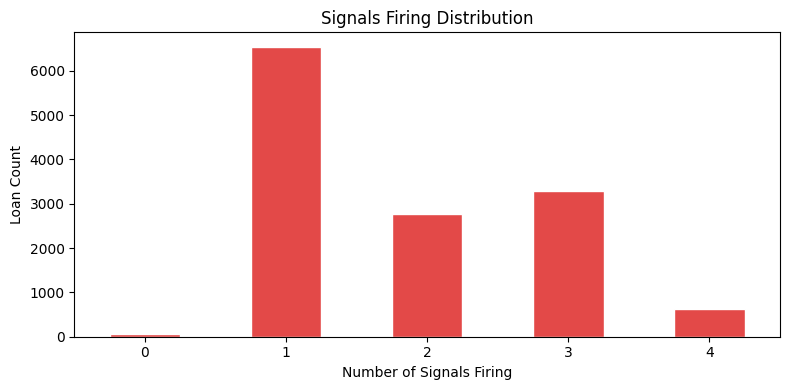

In [45]:
# Signals firing distribution )

signals_combined["signals_firing"].value_counts().sort_index().plot(
    kind="bar", color="#e34948", edgecolor="white", figsize=(8,4)
)
plt.title("Signals Firing Distribution")
plt.xlabel("Number of Signals Firing")
plt.ylabel("Loan Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../eda_outputs/signal_firing_dist.png", dpi=150)
plt.show()

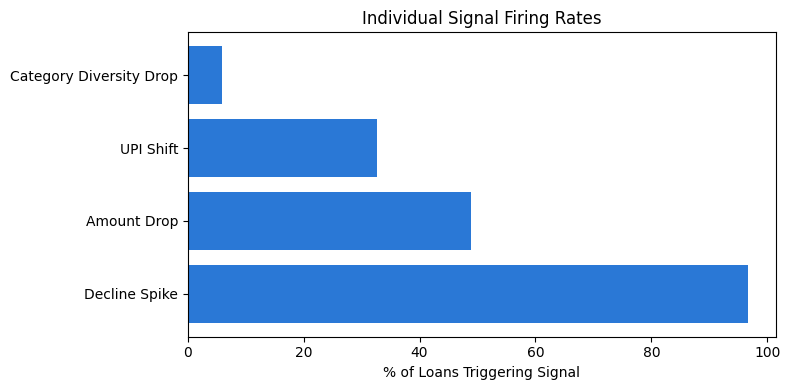

In [46]:
# Signal-level firing rates

signal_cols = ['decline_spike_flag','amount_drop_flag','upi_shift_flag','diversity_drop_flag']
labels = ['Decline Spike','Amount Drop','UPI Shift','Category Diversity Drop']
rates = [signals_combined[c].mean()*100 for c in signal_cols]

plt.figure(figsize=(8,4))
plt.barh(labels, rates, color="#2a78d6")
plt.xlabel("% of Loans Triggering Signal")
plt.title("Individual Signal Firing Rates")
plt.tight_layout()
plt.savefig("../eda_outputs/signal_firing_rates.png", dpi=150)
plt.show()

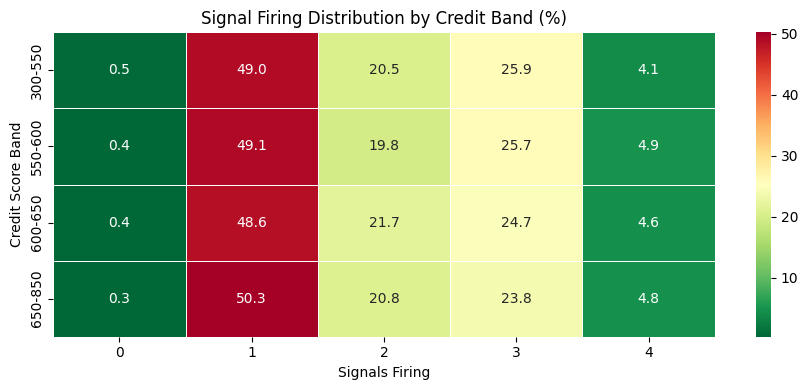

In [47]:
# Signals firing vs credit band (heatmap)

heatmap_data = signals_combined.groupby("credit_score_band")["signals_firing"].value_counts(normalize=True).mul(100).unstack(fill_value=0)

plt.figure(figsize=(9,4))
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="RdYlGn_r", linewidths=0.5)
plt.title("Signal Firing Distribution by Credit Band (%)")
plt.ylabel("Credit Score Band")
plt.xlabel("Signals Firing")
plt.tight_layout()
plt.savefig("../eda_outputs/signal_band_heatmap.png", dpi=150)
plt.show()

#### Saving the Combined Singnals

In [48]:
signals_combined.to_csv("../data/processed/signals_combined.csv", index=False)

#### Findings

    1. Of 33,183 DPD30 events, only 7,721 (23.3%) had any transaction activity in the 30-day pre-default window. The remaining 76.7% went silent — zero transactions pre-default. Transaction silence itself is a stronger pre-default signal than any behavioral change metric in this dataset.

    2. 50.3% of loans in the signals table fire 2+ behavioral signals simultaneously in the pre-default window. In a production risk model, 2+ signals would be a hard trigger for collections outreach.

    3. Signal 4 (merchant category diversity drop) is the most structurally sound signal — customers under cash stress consolidate spending to essentials, reducing category breadth. The synthetic data limitations affect Signals 1-3 more than Signal 4.